In [1]:
import scanpy as sc
import muon as mu
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

/ihome/ylee/yiz133/.local/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-10-10 13:20:12.945901: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-10 13:20:13.226044: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors fro

In [2]:
def lR_to_l(adata, mapper={'leiden_R': 'leiden'}):
    for current_col_name in mapper:
        new_col_name = mapper[current_col_name]
        current_col = adata.obs[current_col_name].copy()
        adata.obs.drop(columns=current_col_name)
        adata.obs[new_col_name] = current_col
    return

def reset_colors(adata, key='leiden', use_plt=True):
    if use_plt:
        try:
            del(adata.uns['plt']['color'][key])
        except:
            pass
    else:
        try:
            del(adata.uns['%s_colors' % key])
        except:
            pass
    return

def relabel_clusts(adata, key='leiden'):
    try:
        adata.obs[key].cat
    except AttributeError:
        adata.obs[key] = adata.obs[key].astype('category')
        
    cats = adata.obs[key].cat.categories
    new_cats = [str(i) for i in range(len(cats))]
    adata.obs[key] = adata.obs[key].map(dict(zip(cats, new_cats)))
    adata.obs[key] = adata.obs[key].astype('category')
    
    reset_colors(adata, key=key)
    
    return

def clean_leiden(adata):
    lR_to_l(adata)
    relabel_clusts(adata)

In [5]:
%%time
%%capture

# mdata = mu.read_10x_h5('/Users/koush/Downloads/lupus_kidney_sep16.h5')
# mdata_raw = mu.read_10x_h5('/Users/koush/Downloads/raw_feature_bc_matrix.h5')

mdata = mu.read_10x_h5('/ix1/ylee/kor11/cellranger/kidney_sep16/kidney_spatial_from_spro/outs/filtered_feature_bc_matrix.h5')
mdata_raw = mu.read_10x_h5('/ix1/ylee/kor11/cellranger/kidney_sep16/kidney_spatial_from_spro/outs/raw_feature_bc_matrix.h5')
mdata_raw.var_names_make_unique()
mdata.var_names_make_unique()

CPU times: user 3.91 s, sys: 329 ms, total: 4.23 s
Wall time: 5.61 s


In [6]:
mdata_raw['rna'].obs["log10umi"] = np.array(np.log10(mdata_raw['rna'].X.sum(axis=1) + 1)).reshape(-1)
filtered_prot = mdata_raw['prot'][:, ~mdata_raw['prot'].var_names.str.contains('Sample')]
mdata_raw.mod['prot'] = filtered_prot
filtered_prot = mdata['prot'][:, ~mdata['prot'].var_names.str.contains('Sample')]
mdata.mod['prot'] = filtered_prot

In [7]:
prot = mdata.mod['prot']
isotypes = mdata_raw['prot'].var_names[
    mdata_raw['prot'].var_names.str.contains('Isotype')].tolist()
isotypes

[]

In [8]:
from muon import prot as pt

In [9]:
prot.layers['counts'] = prot.X
pt.pp.dsb(
    mdata, 
    mdata_raw, 
    empty_counts_range=(1.5, 2.8), 
    isotype_controls=isotypes, 
    random_state=1
)

/scratch/slurm-6573718/ipykernel_720989/378443140.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  prot.layers['counts'] = prot.X
/scratch/slurm-6573718/ipykernel_720989/378443140.py:2: DeprecationWarning: empty_counts_range will be deprecated in the future versions
  pt.pp.dsb(
/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/muon/_prot/preproc.py:137: UserWarning: Dropping 239 empty droplets as they are already defined as cells
  warn(
/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var


In [10]:
sc.tl.pca(prot)

In [11]:
protein_names = {
    'Ms.CD4': 'Cd4',
    'Ms.CD8a': 'Cd8a',
    'Ms.CD366': 'Havcr2',
    'Ms.CD279': 'Pdcd1',
    'Ms.Ly.6C': 'Ly6c1',
    'HuMs.CD11b': 'Itgam',
    'Ms.Ly.6G': 'Ly6g',
    'HuMs.CD49f': 'Itga6',
    'HuMs.CD44': 'Cd44',
    'Ms.CD54': 'Icam1',
    'Ms.CD90.2': 'Thy1',
    'Ms.CD73': 'Nt5e',
    'Ms.CD49d': 'Itga4',
    'Ms.CD200': 'Cd200',
    'Ms.CD19': 'Cd19',
    'Ms.CD45': 'Ptprc',
    'Ms.CD25': 'Il2ra',
    'HuMs.CD45R_B220': 'Ptprc',
    'Ms.CD115': 'Csf1r',
    'Ms.CD11c': 'Itgax',
    'Ms.CD21_CD35': 'Cr2',
    'Ms.CD23': 'Fcer2a',
    'Ms.CD43': 'Spn',
    'Ms.CD5': 'Cd5',
    'Ms.CD62L': 'Sell',
    'Ms.CD93': 'Cd93',
    'Ms.F4_80': 'Adgre1',
    'Ms.FceRIa': 'Fcer1a',
    'Ms.I.A_I.E': 'H2-Ab1',
    'Ms.NK.1.1': 'Klrb1c',
    'Ms.Siglec_H': 'Siglech',
    'Ms.TCR.Bchain': 'Tcrb',
    'Ms.TCR.RD_GL3': 'Tcrd',
    'Ms.TER.119': 'Ly76',
    'Ms.Ly.6A_E': 'Ly6a',
    'Ms.CD45.2': 'Ptprc',
    'HuMsRt.CD278': 'Icos',
    'Ms.CD3': 'Cd3e',
    'Ms.CD274': 'Cd274',
    'HuMsRt.CD27': 'Cd27',
    'Ms.CD20': 'Ms4a1',
    'Ms.CD357': 'Tnfrsf18',
    'Ms.CD137': 'Tnfrsf9',
    'Ms.CD134': 'Tnfrsf4',
    'Ms.CD69': 'Cd69',
    'Ms.CD127': 'Il7r',
    'Ms.CD86': 'Cd86',
    'Ms.CD103': 'Itgae',
    'Ms.CD150': 'Slamf1',
    'Ms.CD24': 'Cd24a',
    'HuMs.integrin.b7': 'Itgb7',
    'Ms.CD106': 'Vcam1',
    'Ms.CD183': 'Cxcr3',
    'Ms.CD8b': 'Cd8b1',
    'Ms.TCR.Vb8.1_8.2': 'Trbv13',
    'HuMs.KLRG1': 'Klrg1',
    'Ms.TCR.Vb5.1_5.2': 'Trbv5',
    'Ms.CD223': 'Lag3',
    'Ms.CD163': 'Cd163',
    'Ms.CD49b': 'Itga2',
    'Ms.CD172a': 'Sirpa',
    'Ms.CD48': 'Cd48',
    'Ms.CD170': 'Siglec5',
    'Ms.CD169': 'Siglec1',
    'Ms.CD71': 'Tfrc',
    'Ms.CD41': 'Itga2b',
    'Ms.CD304': 'Nrp1',
    'Ms.CD38': 'Cd38',
    'Ms.CD55': 'Cd55',
    'Ms.CD63': 'Cd63',
    'Ms.CD301b': 'Mgl2',
    'Ms.Tim.4': 'Timd4',
    'MsRt.CD29': 'Itgb1',
    'Ms.IgD': 'Ighd',
    'Ms.CD11a': 'Itgal',
    'Ms.CD200R': 'Cd200r1',
    'Ms.CCR3': 'Ccr3',
    'Ms.CD138': 'Sdc1',
    'Ms.CD317': 'Bst2',
    'Ms.CD9': 'Cd9',
    'Ms.CD371': 'Clec12a',
    'Ms.CD22': 'Cd22',
    'Ms.Ly49H': 'Klra8',
    'Ms.Ly49D': 'Klra4',
    'Ms.Ly.49A': 'Klra1',
    'Ms.CD185': 'Cxcr5',
    'Ms.CD49a': 'Itga1',
    'Ms.CD1d': 'Cd1d1',
    'Ms.CD226_10E5': 'Cd226',
    'Ms.CD272': 'Btla',
    'Ms.CD2': 'Cd2',
    'Ms.CD120b': 'Tnfrsf1b',
    'Ms.CD40': 'Cd40',
    'Ms.CD31': 'Pecam1',
    'Ms.CD107a': 'Lamp1',
    'Ms.CD182': 'Cxcr2',
    'MsRt.CD61': 'Itgb3',
    'Ms.VISTA': 'Vsir',
    'Ms.CD186': 'Cxcr6',
    'Ms.Ly108': 'Slamf6',
    'Ms.TCR.Va2': 'Trav14',
    'Ms.TCR.Va8.3_KT50': 'Trav8',
    'Ms.TCR.GD_UC7': 'Tcrg',
    'Ms.CD98': 'Slc3a2',
    'Ms.CD160': 'Cd160',
    'Ms.CD51': 'Itgav',
    'Ms.CD94': 'Klrd1',
    'Ms.CD205': 'Ly75',
    'Ms.CD155': 'Pvr',
    'Ms.CD88': 'C5ar1',
    'Ms.FR4': 'Folr4',
    'Ms.CD45RB': 'Ptprc',
    'MsRt.CD81': 'Cd81'
}

In [12]:
rna = mdata.mod['rna']
rna.var['mt'] = rna.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(
    rna, 
    qc_vars=['mt'], 
    percent_top=None, 
    log1p=False, 
    inplace=True
)

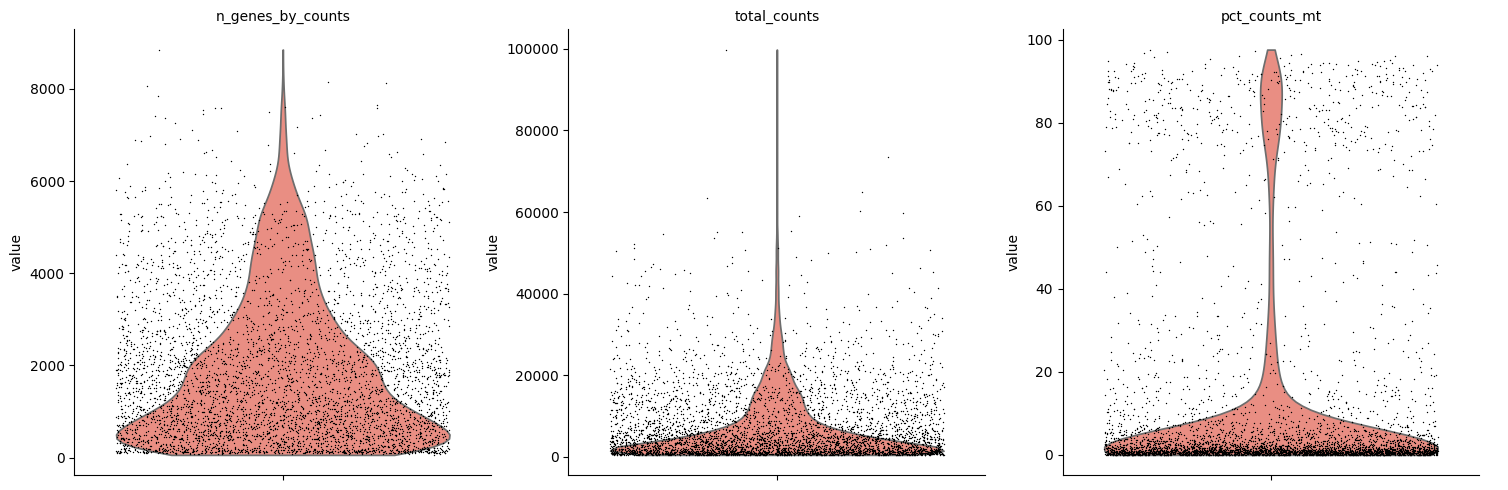

In [13]:
sc.pl.violin(
    rna,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True,
    color='salmon',
)

In [14]:
mu.pp.filter_var(rna, 'n_cells_by_counts', lambda x: x >= 3)
mu.pp.filter_obs(rna, 'n_genes_by_counts', lambda x: (x >= 100) & (x < 5000))
mu.pp.filter_obs(rna, 'total_counts', lambda x: (x > 1500) & (x < 15000))
mu.pp.filter_obs(rna, 'pct_counts_mt', lambda x: x < 20)

In [15]:
rna.layers['raw'] = rna.X.copy()

In [16]:
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, min_mean=0.02, max_mean=4, min_disp=0.5)
sc.tl.pca(rna, svd_solver='arpack')

In [17]:
np.array([i for i in prot.var_names if 'TCR' in i])

array([], dtype=float64)

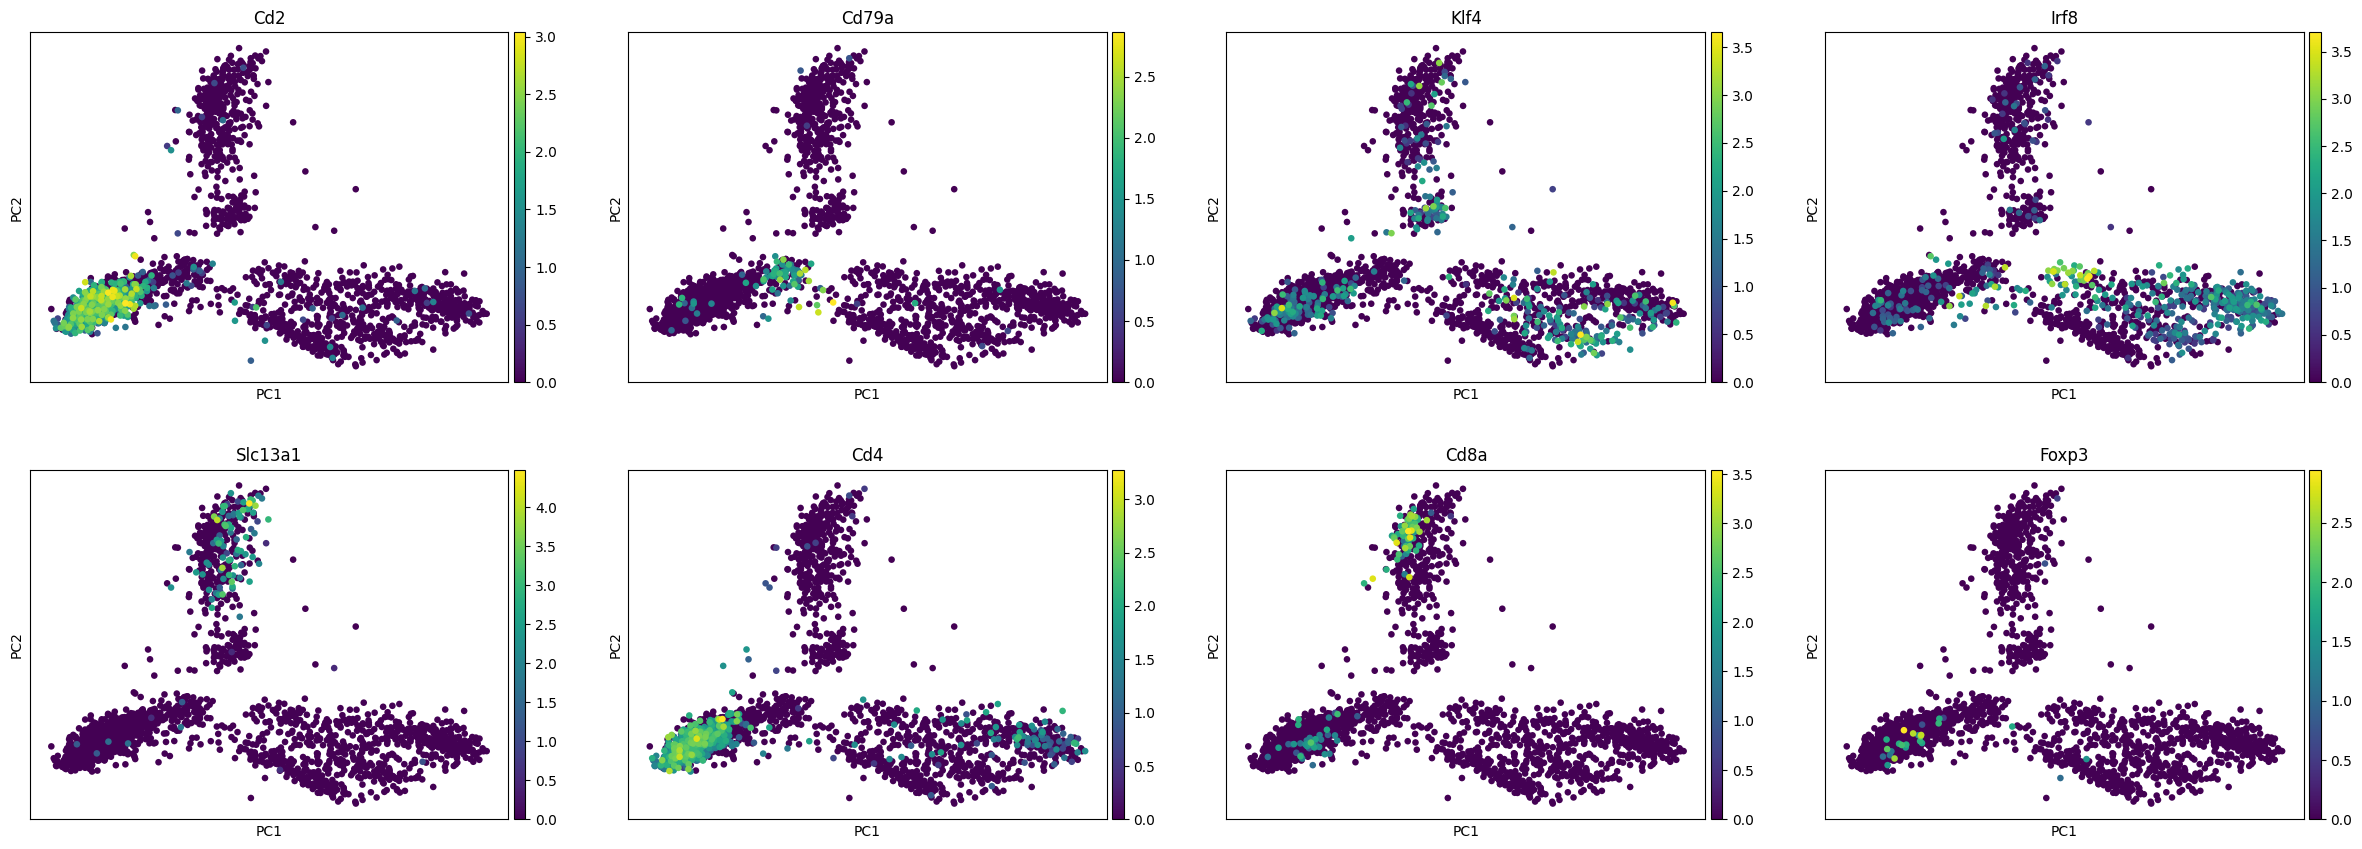

In [18]:
sc.pl.pca(rna, color=['Cd2', 'Cd79a', 'Klf4', 'Irf8', 'Slc13a1', 'Cd4', 'Cd8a', 'Foxp3'], s=90)

In [19]:
rna = rna[:, ~rna.var_names.str.endswith('Rik')]
rna  = rna[:, ~rna.var_names.str.contains(r'^Hb\w+-\w+$')]
rna = rna[:, ~rna.var_names.str.contains('Hp')]
rna = rna[:, ~rna.var_names.str.startswith('Rp')]
rna = rna[:, ~rna.var_names.str.startswith('n-R5s')]
rna = rna[:, ~rna.var_names.str.startswith('n-R5')]
rna = rna[:, ~rna.var_names.str.startswith('AA')]
rna = rna[:, ~rna.var_names.str.startswith('AB')]
rna = rna[:, ~rna.var_names.str.startswith('AC')]
rna = rna[:, ~rna.var_names.str.startswith('Mir')]

In [20]:
sc.pp.neighbors(rna, n_neighbors=50, n_pcs=20)

In [21]:
sc.tl.umap(rna, min_dist=0.8, spread=0.8)

In [22]:
sc.tl.leiden(rna, resolution=0.3, flavor="igraph", n_iterations=2)

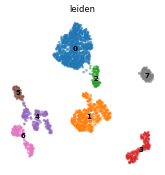

In [23]:
plt.rcParams['figure.figsize'] = (4, 4)
plt.rcParams['figure.dpi'] = 50
sc.pl.umap(
    rna, 
    color=['leiden'], 
    legend_loc='on data', 
    frameon=False, 
    alpha=0.6, 
    s=50,
    linewidth=0.0, 
    edgecolor='black'
)

In [24]:
sc.tl.leiden(rna, resolution=0.3, flavor="igraph")
sc.tl.leiden(rna, resolution=0.2, restrict_to=('leiden', ['7']), flavor="igraph")
clean_leiden(rna)

sc.tl.leiden(rna, resolution=0.2, restrict_to=('leiden', ['5']), flavor="igraph")
clean_leiden(rna)

sc.tl.leiden(rna, resolution=0.125, restrict_to=('leiden', ['2']), flavor="igraph")
clean_leiden(rna)

sc.tl.leiden(rna, resolution=0.2, restrict_to=('leiden', ['3']), flavor="igraph")
clean_leiden(rna)

sc.tl.leiden(rna, resolution=0.4, restrict_to=('leiden', ['12']), flavor="igraph")
clean_leiden(rna)

sc.tl.leiden(rna, resolution=0.35, restrict_to=('leiden', ['0']), flavor="igraph")
clean_leiden(rna)

sc.tl.leiden(rna, resolution=0.2, restrict_to=('leiden', ['2']), flavor="igraph")
clean_leiden(rna)

sc.tl.leiden(rna, resolution=0.2, restrict_to=('leiden', ['0']), flavor="igraph")
clean_leiden(rna)

sc.tl.leiden(rna, resolution=0.35, restrict_to=('leiden', ['1']), flavor="igraph")
clean_leiden(rna)

plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['figure.dpi'] = 200
sc.pl.umap(
    rna, 
    color=['leiden'], 
    legend_loc='on data', 
    frameon=False, 
    alpha=1, 
    s=100,
    linewidth=0.05, 
    edgecolor='black'
)

ValueError: '12' is not a valid category for 'leiden'

In [ ]:
plt.rcParams['figure.figsize'] = (4, 4)
plt.rcParams['figure.dpi'] = 200

umap_params = {
    'legend_loc': "on data",
    's': 30,
    'add_outline': True,
    'ncols': 3,
    'frameon': False
}

In [ ]:
#renal principal cell
sc.pl.umap(rna, color=['Aqp2', 'Aqp3', 'Cdh16', 'Mal', 'Cobll1', 'Pkhd1'], **umap_params)

In [ ]:
#endothelial cell
sc.pl.umap(rna, color=['Cd34', 'Pecam1', 'Ptprb', 'Meis2', 'Flt1', 'Emcn'], **umap_params)

In [ ]:
# NK/T cells
sc.pl.umap(rna, color=['Cd247', 'Ccl4', 'Gzma', 'Ccl5', 'Cd8a', 'Fcgr2b'], **umap_params)

In [ ]:
# proximal tubule S1-S2
sc.pl.umap(rna, color=['Slc5a12', 'Slc13a3', 'Slc22a6', 'Slc5a2'], **umap_params)

In [ ]:
# proximal tubule S3
sc.pl.umap(rna, color=['Slc22a7', 'Mogat1', 'Slc7a13', 'Slc5a8', 'Satb2', 'Slc5a11'], 
    **umap_params)

In [ ]:
#neutrophil
sc.pl.umap(rna, color=['S100a9', 'S100a8', 'Ifitm2'], **umap_params)

In [ ]:
#connecting tubule epithelial cell CNT
sc.pl.umap(rna, color=['Pcdh7'], **umap_params)

In [ ]:
#monocyte-derived dendritic cell
sc.pl.umap(rna, color=['Msr1', 'Itgax', 'Csf2ra', 'Cd14', 'Trpm2'], **umap_params)

In [ ]:
# dendritic cell
sc.pl.umap(rna, color=['Itgax', 'Csf2ra', 'Ciita', 
    'Wdfy4', 'Flt3', 'Cadm1', 'Zbtb46', 'Clec9a'], **umap_params)

In [ ]:
# intercalated cell
sc.pl.umap(rna, color=['Tmem213', 'Atp6v1c2', 'Atp6v0d2'], **umap_params)

In [ ]:
#kidney loop of Henle ascending limb epithelial cell
sc.pl.umap(rna, color=['Casr', 'Slc12a1', 'Umod'], **umap_params)

In [ ]:
#podocytes
sc.pl.umap(rna, color=['Wt1', 'Podxl', 'Nphs2'], **umap_params)

In [ ]:
#distal convoluted tubule
sc.pl.umap(rna, color=['Trpm7', 'Slc8a1', 'Calb1'], **umap_params)

In [ ]:
#collecting duct
sc.pl.umap(rna, color=['Pappa', 'Fxyd4', 'Pde10a'], **umap_params)

In [ ]:
# M1 macrophage markers
sc.pl.umap(rna, color=['Cd80', 'Cd86', 'Nos2', 'Tnf', 'Il1b', 'Il6', 'Il12b'], **umap_params)

# M2 macrophage markers
sc.pl.umap(rna, color=['Mrc1', 'Cd163', 'Msr1', 'Arg1', 'Il10', 'Tgfb1'], **umap_params)


In [ ]:
#immune cells
sc.pl.umap(rna, color=[
    'Adgre1', 'Csf1r', 'Ly86'], 
    **umap_params)

In [ ]:
#immune cells
sc.pl.umap(rna, color=[
    'Ptprc', 'Cd8a', 'Cd4', 'Adgre1', 'Pax5', 'Bcl6', 'Il2ra', 'Gata3', 'Cd79b'], 
    **umap_params)

In [ ]:
#immune cells
sc.pl.umap(rna, color=[
    'Il2ra', 'Gata3', 'Foxp3', 'Tbx21'], 
    **umap_params)

In [ ]:
rna.obs['celltype'] = rna.obs['leiden'].astype(str).replace({
    '19': 'collecting duct',
    '17': 'endothelial cell',
    '4': 'CD8 T',
    '16': 'proximal tubule S1-S2',
    '15': 'proximal tubule S3',
    '13': 'proximal tubule S3',
    '14': 'renal principal cell',
    '12': 'neutrophil',
    '9': 'dendritic cell',
    '18': 'distal convoluted tubule',
    '20': 'loop of Henle',
    '8': 'M2 macrophage',
    '2': 'B cells',
    '3': 'CD4 T',
    '0': 'CD4 T',
    '6': 'CD4 T',
    '5': 'CD4 T',
    '1': 'CD4 T',
    '7': 'M1 macrophage',
    '10': 'monocytes',
    '11': 'plasma',
    '21': 'erythrocytes',
})

In [ ]:
%matplotlib inline

figure_params = {
    'dpi': 300, 
    'bbox_inches': 'tight', 
    'format': 'svg', 
    'transparent': True
}

plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": 'none'
})

In [ ]:
import seaborn as sns
from adjustText import adjust_text

plt.rcParams['figure.figsize'] = (12, 12)
plt.rcParams['figure.dpi'] = 300

umap = rna.obsm['X_umap']
celltypes = rna.obs['celltype']
df = rna.obs.copy()
df['UMAP1'] = umap[:, 0]
df['UMAP2'] = umap[:, 1]

fig, ax = plt.subplots(dpi=300, figsize=(12, 12))
sns.scatterplot(
    data=df, x='UMAP1', y='UMAP2', hue='celltype',
    s=100, edgecolor='black', 
    linewidth=0.05, alpha=1, ax=ax, legend=False
)

texts = []
for celltype, group in df.groupby('celltype'):
    x = group['UMAP1'].median()
    y = group['UMAP2'].median()
    texts.append(ax.text(x, y, celltype, fontsize=12, weight='bold'))

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

plt.axis('off')
plt.savefig('/tmp/umap.svg', **figure_params)
plt.show()


In [ ]:
rna

In [ ]:
prot = prot[rna.obs_names]

In [ ]:
prot

In [ ]:
prot.obsm['X_umap'] = rna.obsm['X_umap'].copy()

In [ ]:
prot.var_names

In [ ]:
rna

In [ ]:
plt.rcParams['figure.figsize'] = (5, 5)
plt.rcParams['figure.dpi'] = 200
sc.pl.umap(rna, color=[
    'Cd4', 'Cd8a', 'total_counts', 
    'n_genes_by_counts', 'Cd69', 'Cd38', 'Icos', 'celltype'], s=100)

In [ ]:
[i for i in prot.var_names if '80' in i]

In [ ]:
plt.rcParams['figure.figsize'] = (5, 5)
plt.rcParams['figure.dpi'] = 200
sc.pl.umap(prot, color=['Ms.F4_80', 'Ms.CD8a', 'Ms.CD4'], s=100, frameon=False)